<a href="https://colab.research.google.com/github/karlssoj/cv26/blob/Example2_catsDogsClassification_and_transferLearning/Cats_Dogs_classifier_3layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Inträning av klassificeringsmodell, som klassificerar hund och katt </h1>

**Laddar ner cats & dogs dataset**

In [1]:
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

--2026-02-10 08:53:14--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.62.176.164, 2600:1406:bc00:1084::317f, 2600:1406:bc00:1085::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.62.176.164|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   255MB/s    in 3.1s    

2026-02-10 08:53:17 (255 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



<b> Packar upp ZIP-filen



In [2]:
!unzip kagglecatsanddogs_5340.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

**Tar bort de "korrupta" bildfilerns**

In [3]:
!rm /content/PetImages/Cat/666.jpg
!rm /content/PetImages/Dog/11702.jpg

<b> Installerar split-folders, för att enkelt kunna dela upp ett bildataset i test, train och val

In [4]:
!pip install split-folders

<b> Importerar alla libs som behövs

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Input
import splitfolders
import matplotlib.pyplot as plt

<B> Delar in träningsbilderna i validation 10%, test 10% och training 80%. Detta alltså delar upp de ursprungliga hund- och kattkatalogerna i 3 olika kataloger som sparas under Petimages_Split

In [6]:
# Path to original dataset
input_folder = "/content/PetImages"  # The folder containing "Cat" and "Dog" subfolders

# Split into train (80%), validation (10%), and test (10%)
splitfolders.ratio(input_folder, output="PetImages_Split", seed=42, ratio=(0.8, 0.1, 0.1), group_prefix=None)

Copying files: 25000 files [00:04, 5562.97 files/s]


<b> Skapar ett ImageDataGenerator-objekt med vissa inställningar för data augumentering

In [7]:
image_gen = ImageDataGenerator(rotation_range=30,    #slumpmässiga roteringar av bilderna i grader
                             width_shift_range=0.1,  #slumpmässig skiftning i x-led (ett värde mellan 0 och 1)
                             height_shift_range=0.1, #slumpmässig skiftning i y-led (ett värde mellan 0 och 1)
                             rescale=1/255,          #skalar ner ett 8-bitars pixelvärde (0-255) till ett värde mellan 0 och 1
                             zoom_range=0.6,         #slumpmässig zoom
                             horizontal_flip=True)   #"flippar" bilden slumpmässigt i horisontalt läge

<b> Läser in train, validation och testbilderna till 3 olika objekt

In [8]:
train_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/train",
    target_size=(100, 100)
)

validation_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/val",
    target_size=(100, 100)
)

test_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/test",
    target_size=(100, 100)
)

Found 19998 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


<b> Skapar neuronätet

In [16]:
model = Sequential()
model.add(Input(shape=(100, 100, 3)))

# Lager 1
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Lager 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Lager 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

#Vi sätter in flera lagar här på slutet för att kunna kombinera ihop fler features och träna mera avancerade egenskaper
model.add(Flatten())
model.add(Dense(units=128, activation="relu"))  # Hidden layer
model.add(Dense(units=64, activation="relu"))   # Ytterligare hidden layer
model.add(Dense(units=2, activation="sigmoid"))  # Output                       #

<b> "Kompilerar" modellen och definierar loss function och optimizer

In [17]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [18]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,162 (6.64 MB)

 Trainable params: 1,740,162 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

<b> Startar själva inträning. Epochs definierar hur många ggr inlärningsalgoritmen kommer att gå igenom hela datasetet. Vi definierar även var valideringsbilderna finns som ska tas i beaktand under inträning

In [19]:
results = model.fit(train_image_gen,
                    validation_data=validation_image_gen,
                    epochs=10)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 143ms/step - accuracy: 0.5242 - loss: 0.6894 - val_accuracy: 0.5948 - val_loss: 0.6613
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.6145 - loss: 0.6560 - val_accuracy: 0.6636 - val_loss: 0.5968
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.6826 - loss: 0.5938 - val_accuracy: 0.7044 - val_loss: 0.5675
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.7043 - loss: 0.5691 - val_accuracy: 0.7260 - val_loss: 0.5437
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.7215 - loss: 0.5473 - val_accuracy: 0.7360 - val_loss: 0.5185
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.7286 - loss: 0.5306 - val_accuracy: 0.7496 - val_loss: 0.5036
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.7426 - loss: 0.5209 - val_accuracy: 0.7512 - val_loss: 0.5174
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.7541 - loss: 0

<b> Ritar ut i ett diagram training och validatio accuracy över antalet epocs

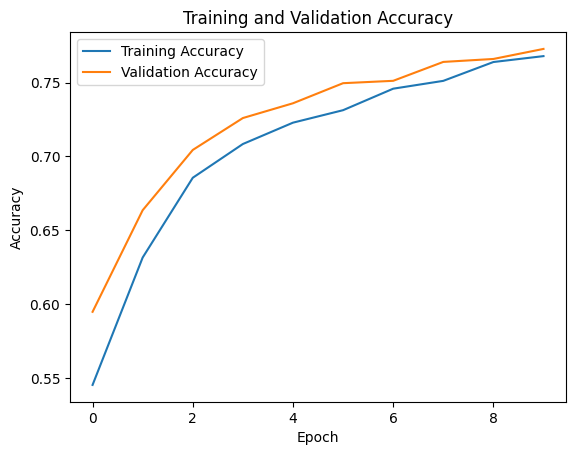

In [20]:

plt.plot(results.history['accuracy'], label='Training Accuracy')
plt.plot(results.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

<B> Evaluerar vår klassificeringsmodell mot testdatasetet

In [21]:
test_loss, test_acc = model.evaluate(test_image_gen)
print(f"Test Accuracy: {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.7833 - loss: 0.4629
Test Accuracy: 0.7692
